# 1. Intro

ALA MA KOTA ^^

# 2. Dane

## Wczytanie danych

In [214]:
import pandas as pd

In [215]:
df = pd.read_csv('Letterbox Movie Classification Dataset.csv')

df.head(3)

,Unnamed: 0,Film_title,Director,Average_rating,Genres,Runtime,Original_language,Description,Studios,Watches,List_appearances,Likes,Fans,Lowest★,Medium★★★,Highest★★★★★,Total_ratings
0,0,The Fan,Eckhart Schmidt,3.57,"['Horror', 'Drama']",92.0,German,The hero-worship that Simone has for a pop sin...,['Barbara Moorse Workshop'],12841,11032,3763,79,129,1660,714,9042
1,1,Mad Max: Fury Road,George Miller,4.18,"['Adventure', 'Science Fiction', 'Action']",121.0,English,An apocalyptic story set in the furthest reach...,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,927538,38000,12530,158356,511140,1682389
2,2,Suspiria,Dario Argento,3.93,['Horror'],99.0,English,An American newcomer to a prestigious German b...,['Seda Spettacoli'],618171,220094,219548,13000,2814,53427,88628,443757


In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         10000 non-null  int64  
 1   Film_title         10000 non-null  object 
 2   Director           10000 non-null  object 
 3   Average_rating     10000 non-null  float64
 4   Genres             10000 non-null  object 
 5   Runtime            10000 non-null  float64
 6   Original_language  10000 non-null  object 
 7   Description        10000 non-null  object 
 8   Studios            10000 non-null  object 
 9   Watches            10000 non-null  int64  
 10  List_appearances   10000 non-null  int64  
 11  Likes              10000 non-null  int64  
 12  Fans               10000 non-null  int64  
 13  Lowest★            10000 non-null  int64  
 14  Medium★★★          10000 non-null  int64  
 15  Highest★★★★★       10000 non-null  int64  
 16  Total_ratings      1000

## wywalenie niepotrzebnych kolumn

In [217]:
df.drop(columns=['Unnamed: 0', 'Film_title', 'Director', 'Description', 'Studios', 'Lowest★', 'Medium★★★', 'Highest★★★★★'], inplace=True)

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Average_rating     10000 non-null  float64
 1   Genres             10000 non-null  object 
 2   Runtime            10000 non-null  float64
 3   Original_language  10000 non-null  object 
 4   Watches            10000 non-null  int64  
 5   List_appearances   10000 non-null  int64  
 6   Likes              10000 non-null  int64  
 7   Fans               10000 non-null  int64  
 8   Total_ratings      10000 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB


In [219]:
df.head(3)

,Average_rating,Genres,Runtime,Original_language,Watches,List_appearances,Likes,Fans,Total_ratings
0,3.57,"['Horror', 'Drama']",92.0,German,12841,11032,3763,79,9042
1,4.18,"['Adventure', 'Science Fiction', 'Action']",121.0,English,2488721,331681,927538,38000,1682389
2,3.93,['Horror'],99.0,English,618171,220094,219548,13000,443757


## zmiana Genres z 'string' na 'list'

In [220]:
unique_genres = dict()

for i, s in enumerate(df['Genres']):
    s = s.strip("[]").replace("'", "")
    l = []
    for g in s.split(','):
        l.append(g.strip())
        
        unique_genres[g.strip()] = unique_genres.get(g.strip(), 0) + 1
    df.at[i, 'Genres'] = l
    

In [221]:
unique_genres = pd.DataFrame(unique_genres.items(), columns=['Genre', 'Count'])
unique_genres.sort_values(by='Count', ascending=False, inplace=True)

## zostawienie tylko znaczących genres

In [222]:
top_genres = unique_genres[unique_genres['Count']>200]['Genre'].tolist()
top_genres

['Drama',
 'Comedy',
 'Thriller',
 'Action',
 'Horror',
 'Crime',
 'Adventure',
 'Romance',
 'Science Fiction',
 'Fantasy',
 'Mystery',
 'Family',
 'Animation',
 'History',
 'Documentary',
 'War',
 'Music',
 'Western',
 'TV Movie']

In [223]:
columns_to_drop = unique_genres[~unique_genres['Genre'].isin(top_genres)]['Genre'].tolist()
columns_to_drop

['Unknown',
 'Show All…',
 'Epic heroes',
 'Superheroes in action-packed battles with villains',
 'Epic adventure and breathtaking battles',
 'Epic history and literature',
 'Fantasy adventure',
 'heroism',
 'and swordplay',
 'Captivating vision and Shakespearean drama',
 'Historical battles and epic heroism']

## rozbicie genres na osobne kolumny True/False (1/0)

In [224]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genre_encoded = mlb.fit_transform(df['Genres'])

genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

genre_df.drop(columns=columns_to_drop, inplace=True)

df = pd.concat([df, genre_df], axis=1)

df = df.drop('Genres', axis=1)

## **Nowa kolumna 'Rating_Class' (target do classification)**

In [225]:
def rating_class1(rating):

    '''
    Terrible: 0.0 to 2.49  
    Bad: 2.5 to 3.24  
    Average: 3.25 to 3.99  
    Best: 4.0 to 5.0  
    '''

    if rating < 2.5:
        return 'Terrible'
    elif rating < 3.25:
        return 'Bad'
    elif rating < 4:
        return 'Average'
    else:
        return 'Best'

df["Rating_Class1"] = df["Average_rating"].apply(rating_class1)
df['Rating_Class1'].value_counts()

Rating_Class1
Average     4895
Bad         3531
Terrible     798
Best         776
Name: count, dtype: int64

In [226]:
def rating_class2(rating):

    '''
    Bad/Mixed: 0.0 to 3.2  
    Good: 3.2 to 3.9  
    Masterpiece: 3.9 to 5.0   
    '''

    if rating < 3.2:
        return 'Bad/Mixed'
    elif rating < 3.9:
        return 'Good'
    else:
        return 'Masterpiece'

df["Rating_Class2"] = df["Average_rating"].apply(rating_class2)
df['Rating_Class2'].value_counts()

Rating_Class2
Good           4950
Bad/Mixed      3935
Masterpiece    1115
Name: count, dtype: int64

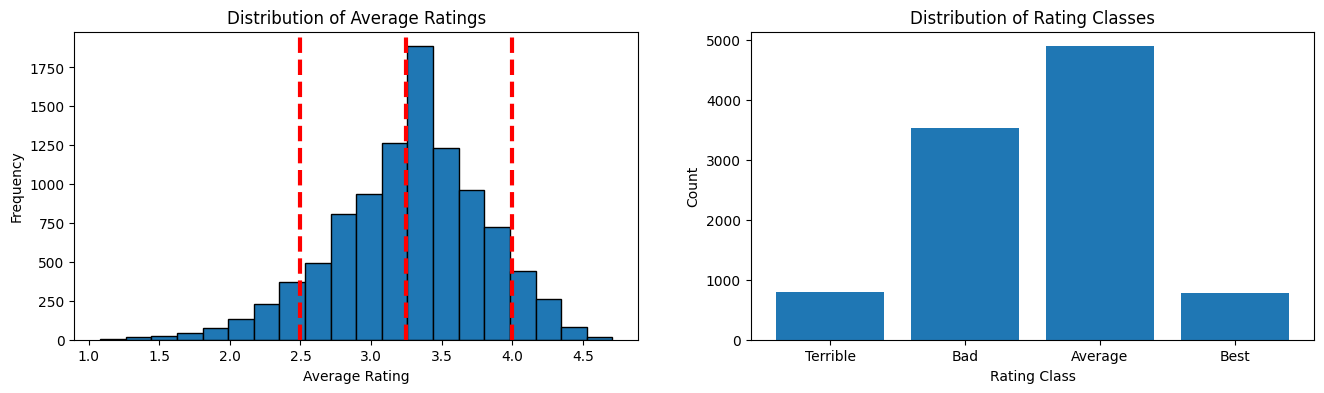

In [235]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 4))

ax1.hist(df['Average_rating'], bins=20, edgecolor='black')
ax1.axvline(x=2.5, color='red', linestyle='dashed', linewidth=3)
ax1.axvline(x=3.25, color='red', linestyle='dashed', linewidth=3)
ax1.axvline(x=4, color='red', linestyle='dashed', linewidth=3)
ax1.set_xlabel('Average Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Average Ratings')

plot_data = df['Rating_Class1'].value_counts()
plot_data = plot_data.reindex(['Terrible', 'Bad', 'Average', 'Best'])
ax2.bar(plot_data.index, plot_data.values)
ax2.set_xlabel('Rating Class')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Rating Classes')

plt.show()

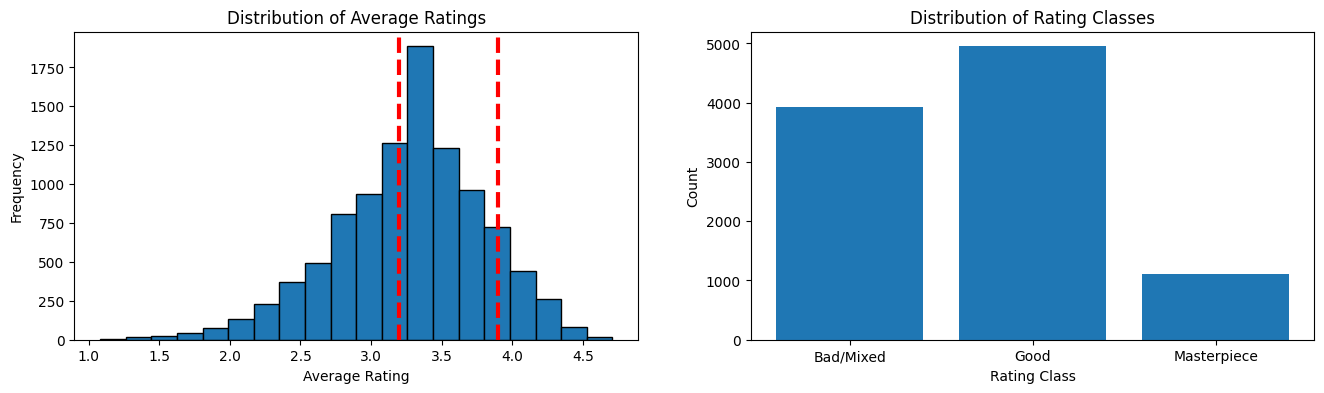

In [236]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 4))

ax1.hist(df['Average_rating'], bins=20, edgecolor='black')
ax1.axvline(x=3.2, color='red', linestyle='dashed', linewidth=3)
ax1.axvline(x=3.9, color='red', linestyle='dashed', linewidth=3)
ax1.set_xlabel('Average Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Average Ratings')

plot_data = df['Rating_Class2'].value_counts()
plot_data = plot_data.reindex(['Bad/Mixed', 'Good', 'Masterpiece'])
ax2.bar(plot_data.index, plot_data.values)
ax2.set_xlabel('Rating Class')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Rating Classes')

plt.show()

In [ ]:
df.drop(columns=['Average_rating'], inplace=True)

# 3. Random Forest (pierwszy)

In [ ]:
df

,Runtime,Original_language,Watches,List_appearances,Likes,Fans,Total_ratings,Action,Adventure,Animation,...,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,Rating_Class1,Rating_Class2
0,92.0,German,12841,11032,3763,79,9042,0,0,0,...,0,0,0,0,0,0,0,0,Average,Good
1,121.0,English,2488721,331681,927538,38000,1682389,1,1,0,...,0,0,0,1,0,0,0,0,Best,Masterpiece
2,99.0,English,618171,220094,219548,13000,443757,0,0,0,...,0,0,0,0,0,0,0,0,Average,Masterpiece
3,102.0,English,1596190,254180,493248,38000,1076949,0,0,0,...,0,0,1,0,0,0,0,0,Average,Good
4,124.0,Japanese,873068,175586,341567,21000,600721,1,0,1,...,0,0,0,1,0,0,0,0,Best,Masterpiece
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,205.0,English,108,163,10,0,56,0,0,0,...,0,0,0,0,1,1,0,0,Average,Good
9996,176.0,German,227,84,45,0,170,0,0,0,...,0,0,0,0,1,0,0,0,Average,Good
9997,89.0,German,82,43,4,0,61,0,0,0,...,0,0,0,0,1,0,0,0,Average,Good
9998,95.0,English,4239,1135,345,0,3274,0,0,0,...,0,0,0,1,0,1,0,0,Terrible,Bad/Mixed


# 4. (drugi)

In [ ]:
df

# 5. (trzeci)

In [ ]:
df